In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data = pd.read_csv("dataset_exercices.csv")
data.head()

,date_inscription,age,genre,region,type_abonnement,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
0,2023-01-01,67,Femme,Maritime,Premium,35.89,2,0,163,6.1,1
1,2023-01-02,35,Homme,Maritime,Premium,40.84,3,0,134,5.9,0
2,2023-01-02,52,Femme,Kara,Premium,40.56,3,0,80,5.2,1
3,2023-01-02,68,Femme,Centrale,Premium,19.10,3,0,166,4.5,0
4,2023-01-02,30,Homme,Centrale,Standard,22.39,0,2,157,5.6,0


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   date_inscription                2000 non-null   str    
 1   age                             2000 non-null   int64  
 2   genre                           2000 non-null   str    
 3   region                          2000 non-null   str    
 4   type_abonnement                 2000 non-null   str    
 5   depense_mensuelle               2000 non-null   float64
 6   nb_commandes_mois_dernier       2000 non-null   int64  
 7   nb_retours                      2000 non-null   int64  
 8   jours_depuis_derniere_commande  2000 non-null   int64  
 9   score_satisfaction              2000 non-null   float64
 10  churn                           2000 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 172.0 KB


In [19]:
data["date_inscription"] = pd.to_datetime(data["date_inscription"])

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date_inscription                2000 non-null   datetime64[us]
 1   age                             2000 non-null   int64         
 2   genre                           2000 non-null   str           
 3   region                          2000 non-null   str           
 4   type_abonnement                 2000 non-null   str           
 5   depense_mensuelle               2000 non-null   float64       
 6   nb_commandes_mois_dernier       2000 non-null   int64         
 7   nb_retours                      2000 non-null   int64         
 8   jours_depuis_derniere_commande  2000 non-null   int64         
 9   score_satisfaction              2000 non-null   float64       
 10  churn                           2000 non-null   int64         
dtypes: datetime64[u

In [21]:
data.describe().round(2)

,date_inscription,age,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
count,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2023-12-31 09:38:09.600000,43.62,38.11,3.16,0.27,92.24,5.86,0.13
min,2023-01-01 00:00:00,18.00,2.00,0.00,0.00,0.00,1.50,0.00
25%,2023-06-29 18:00:00,30.00,25.53,2.00,0.00,49.00,4.90,0.00
50%,2024-01-01 00:00:00,43.00,37.13,3.00,0.00,93.00,5.80,0.00
75%,2024-07-04 00:00:00,57.00,50.06,4.00,0.00,138.00,6.80,0.00
max,2024-12-30 00:00:00,69.00,102.10,10.00,3.00,179.00,10.00,1.00
std,NaN,14.94,18.47,1.83,0.52,51.60,1.37,0.34


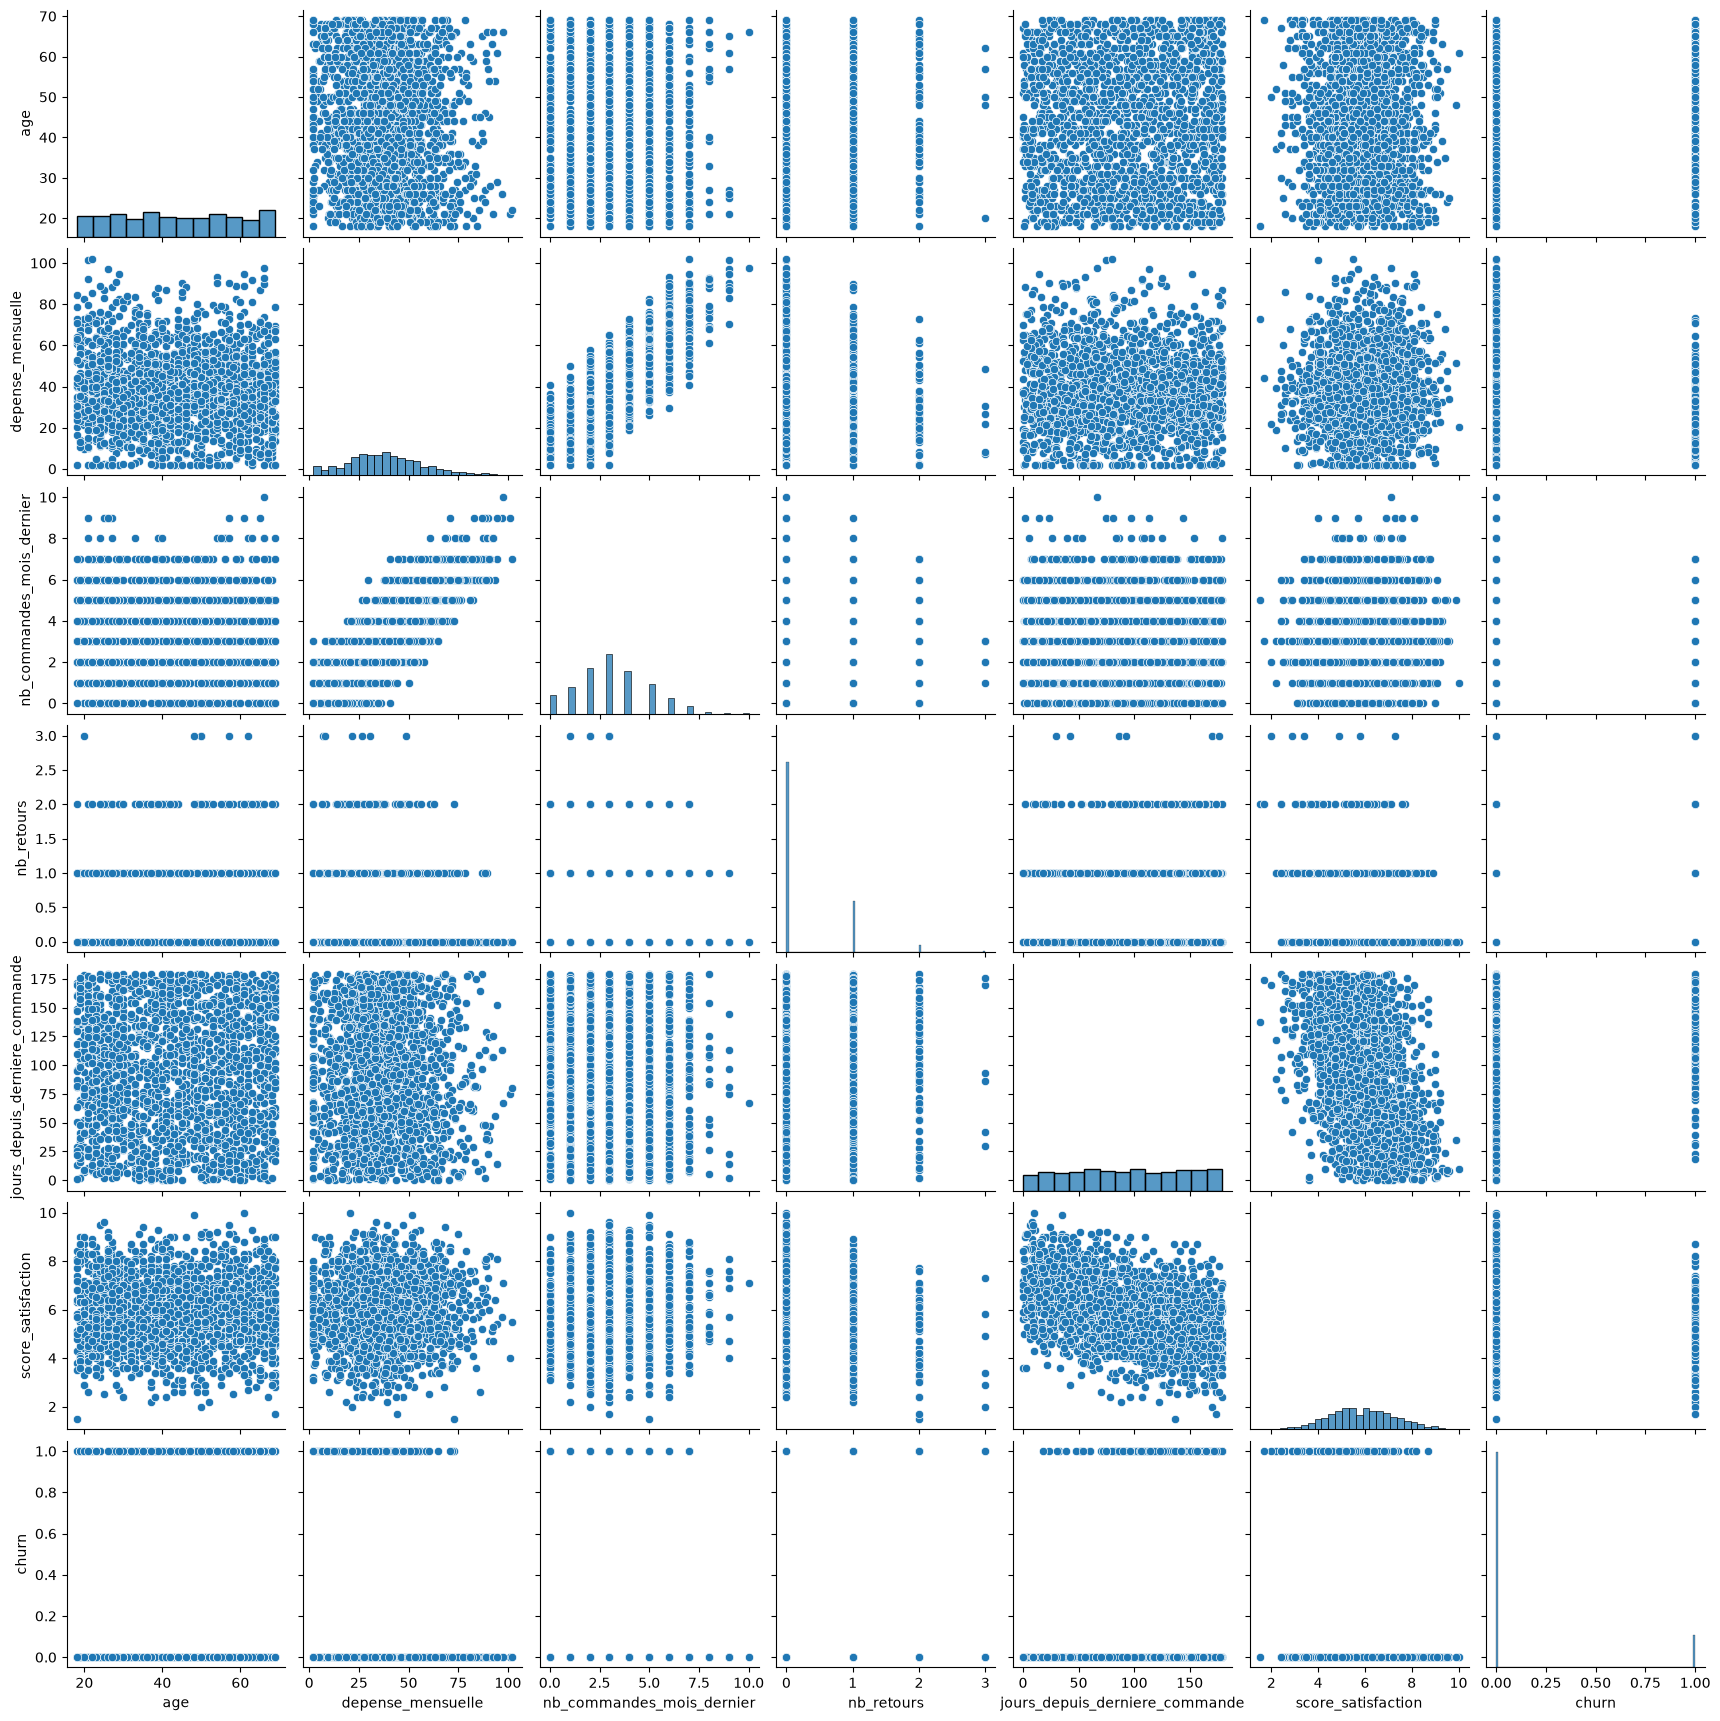

In [22]:
sns.pairplot(data)

- Visualisation des donnees 

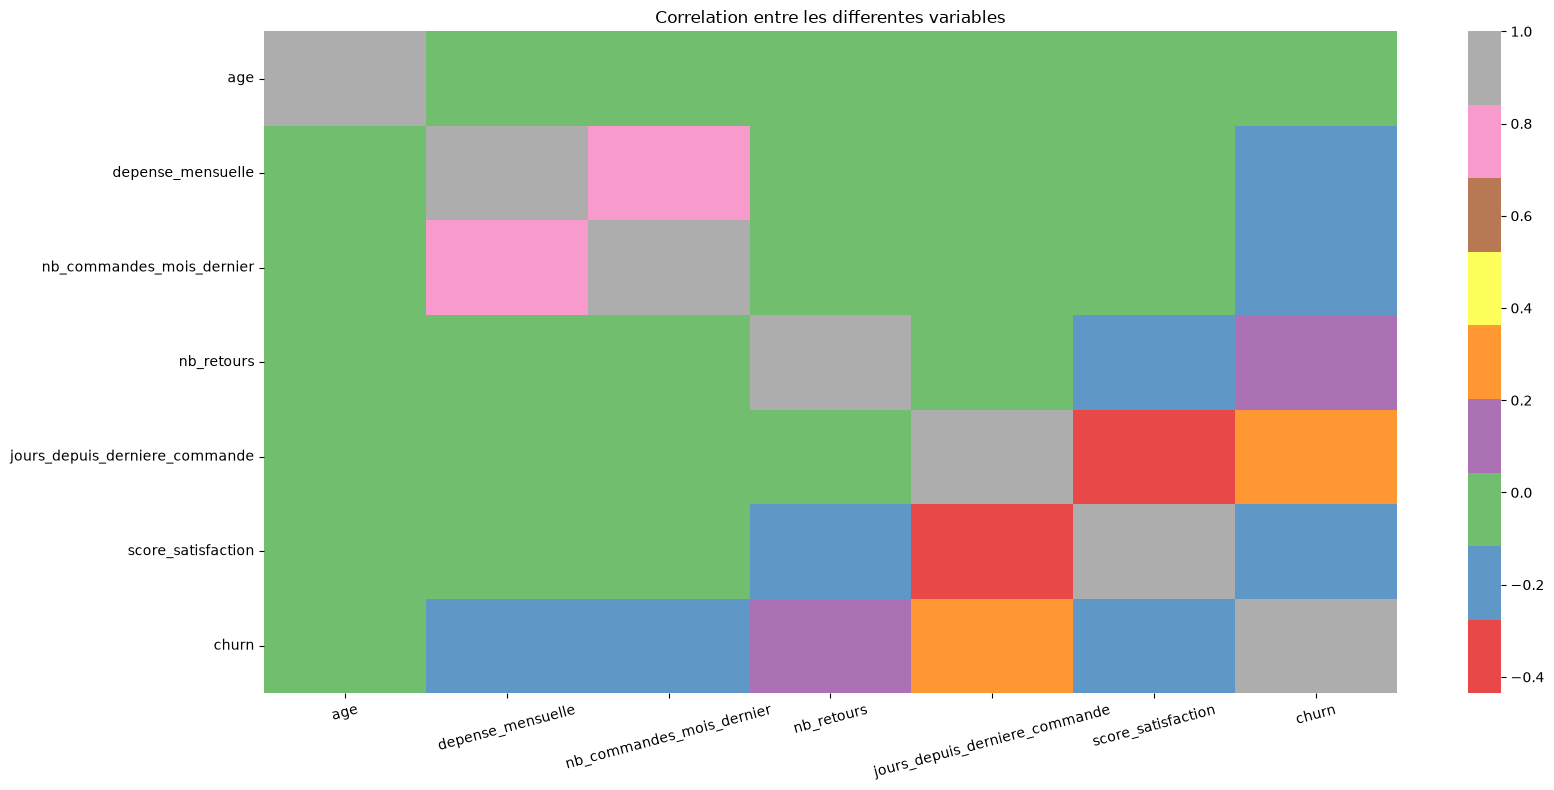

In [23]:
plt.figure(figsize =(17, 8))
plt.title("Correlation entre les differentes variables")
sns.heatmap(data.corr(numeric_only=True),alpha=0.8,cmap="Set1")
plt.xticks(rotation = 15)
plt.tight_layout()
plt.show()

In [24]:
# =============================================================
# LAFIè IA - Pipeline de collecte et simulation des données
# Étape 1 : Données météo réelles (Open-Meteo) + demande en sang
#           simulée et calibrée sur des statistiques réelles du CNTS
# =============================================================
#
# Pourquoi ce changement par rapport à la version précédente ?
# --------------------------------------------------------------
# Le dataset UCI (Blood Transfusion Service Center, Taïwan) ne
# représente ni le Togo, ni une série temporelle de demande.
# On calibre donc désormais notre simulation directement sur des
# statistiques publiques et réelles du CNTS Togo :
#   - Le CNTS ne couvre que ~60% des demandes entre avril et
#     septembre (saison des pluies), contre une meilleure
#     couverture le reste de l'année.
#   - En 2024 : ~70 000 poches collectées sur l'année, mais
#     16,19% des besoins nationaux non satisfaits.
#   - Historiquement (2003-2008), la couverture nationale
#     moyenne tournait autour de 50%.
#
# Ces chiffres servent de PARAMÈTRES DE CALIBRATION (amplitude
# de la saisonnalité, niveau de base) pour la série simulée -
# pas de dataset brut à fusionner.

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. COLLECTE DES DONNÉES MÉTÉO RÉELLES (Open-Meteo, Lomé)
# -------------------------------------------------------------

LATITUDE = 6.1319   # Lomé
LONGITUDE = 1.2228
DATE_DEBUT = "2021-01-01"
DATE_FIN = "2025-12-31"

def recuperer_donnees_meteo(latitude, longitude, date_debut, date_fin):
    """
    Récupère la pluviométrie et la température journalières
    réelles de Lomé via l'API archive d'Open-Meteo.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": date_debut,
        "end_date": date_fin,
        "daily": ["precipitation_sum", "temperature_2m_mean"],
        "timezone": "Africa/Lome",
    }
    reponse = requests.get(url, params=params, timeout=30)
    reponse.raise_for_status()
    donnees = reponse.json()["daily"]

    df_meteo = pd.DataFrame({
        "date": pd.to_datetime(donnees["time"]),
        "pluviometrie_mm": donnees["precipitation_sum"],
        "temperature_moy_c": donnees["temperature_2m_mean"],
    })
    return df_meteo


print("Téléchargement des données météo réelles de Lomé (2021-2025)...")
df_meteo = recuperer_donnees_meteo(LATITUDE, LONGITUDE, DATE_DEBUT, DATE_FIN)
print(f"-> {len(df_meteo)} jours récupérés.")
print(df_meteo.head())


# -------------------------------------------------------------
# 2. SIMULATION CALIBRÉE DE LA DEMANDE EN POCHES DE SANG
# -------------------------------------------------------------
#
# Hypothèse assumée : pluie -> prolifération des moustiques ->
# paludisme -> anémie sévère -> hausse de la demande en poches
# de sang, avec un décalage (les cas graves arrivent quelques
# jours après un épisode pluvieux, pas le jour même).
#
# Paramètres calibrés sur les chiffres réels du CNTS :
#   - DEMANDE_BASE       : niveau moyen journalier de demande
#                          (dérivé de ~70 000 poches/an -> ~192/j)
#   - AMPLITUDE_SAISON    : sur-demande en saison des pluies,
#                          calibrée pour que la période
#                          avril-septembre atteigne un déficit
#                          de couverture d'environ 40% (60% de
#                          couverture observée par le CNTS),
#                          contre un déficit plus faible le
#                          reste de l'année.
#   - DELAI_JOURS         : décalage entre pic de pluie et pic
#                          de demande transfusionnelle (anémie
#                          sévère développée progressivement).
#   - BRUIT               : variabilité aléatoire réaliste
#                          (accidents, autres pathologies, etc.
#                          non capturés par le facteur pluie).

DEMANDE_BASE = 192          # poches / jour, dérivé de 70 000 poches / an (CNTS 2024)
AMPLITUDE_SAISON = 90        # amplitude de la sur-demande liée à la saison des pluies
DELAI_JOURS = 10             # décalage pluie -> pic de demande transfusionnelle
FENETRE_LISSAGE = 21         # lissage du signal pluie pour simuler l'effet cumulatif
NIVEAU_BRUIT = 15            # écart-type du bruit aléatoire (autres causes de demande)

np.random.seed(42)  # reproductibilité (exigence du hackathon)


def simuler_demande_sang(df_meteo, demande_base, amplitude, delai_jours,
                          fenetre_lissage, niveau_bruit):
    """
    Construit une série simulée de demande journalière en
    poches de sang, calibrée sur la pluviométrie réelle et sur
    les statistiques publiques du CNTS Togo (pas sur un dataset
    étranger sans lien avec le pays).
    """
    df = df_meteo.copy()

    # Effet cumulatif de la pluie (moyenne glissante = "réservoir"
    # de gîtes larvaires qui ne s'assèche pas immédiatement)
    pluie_lissee = df["pluviometrie_mm"].rolling(
        window=fenetre_lissage, min_periods=1
    ).mean()

    # Décalage temporel : la demande réagit avec un délai
    signal_paludisme = pluie_lissee.shift(delai_jours).fillna(0)

    # Normalisation du signal pluie en un facteur de sur-demande
    # entre 0 et 1, pour contrôler l'amplitude via AMPLITUDE_SAISON
    if signal_paludisme.max() > 0:
        facteur_normalise = signal_paludisme / signal_paludisme.max()
    else:
        facteur_normalise = signal_paludisme

    bruit = np.random.normal(loc=0, scale=niveau_bruit, size=len(df))

    demande_simulee = (
        demande_base
        + amplitude * facteur_normalise
        + bruit
    )

    # La demande ne peut pas être négative
    demande_simulee = np.clip(demande_simulee, a_min=0, a_max=None)

    df["demande_sang_simulee"] = demande_simulee.round().astype(int)
    return df


print("\nSimulation de la demande en sang calibrée sur les stats CNTS...")
df_final = simuler_demande_sang(
    df_meteo,
    demande_base=DEMANDE_BASE,
    amplitude=AMPLITUDE_SAISON,
    delai_jours=DELAI_JOURS,
    fenetre_lissage=FENETRE_LISSAGE,
    niveau_bruit=NIVEAU_BRUIT,
)


# -------------------------------------------------------------
# 3. VÉRIFICATION DE LA COHÉRENCE AVEC LES CHIFFRES RÉELS
# -------------------------------------------------------------
# On vérifie que notre simulation reproduit bien l'écart de
# couverture avril-septembre vs le reste de l'année observé par
# le CNTS (environ 60% de couverture en saison des pluies).

df_final["mois"] = df_final["date"].dt.month
saison_pluies = df_final["mois"].between(4, 9)

demande_moy_saison = df_final.loc[saison_pluies, "demande_sang_simulee"].mean()
demande_moy_hors_saison = df_final.loc[~saison_pluies, "demande_sang_simulee"].mean()
ecart_pct = (demande_moy_saison / demande_moy_hors_saison - 1) * 100

print(f"\nDemande moyenne en saison des pluies (avril-sept) : {demande_moy_saison:.1f} poches/j")
print(f"Demande moyenne hors saison des pluies            : {demande_moy_hors_saison:.1f} poches/j")
print(f"Écart de demande en saison des pluies              : +{ecart_pct:.1f}%")
print("(À comparer à l'écart de couverture réel observé par le CNTS : ~60% vs le reste de l'année)")


# -------------------------------------------------------------
# 4. SAUVEGARDE DU JEU DE DONNÉES FINAL
# -------------------------------------------------------------

colonnes_finales = ["date", "pluviometrie_mm", "temperature_moy_c", "demande_sang_simulee"]
df_export = df_final[colonnes_finales]
df_export.to_csv("lafie_ia_dataset.csv", index=False)
print(f"\nJeu de données final sauvegardé : lafie_ia_dataset.csv ({len(df_export)} lignes)")


# -------------------------------------------------------------
# 5. VISUALISATION RAPIDE (pluie vs demande simulée)
# -------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Pluviométrie (mm)", color="steelblue")
ax1.plot(df_final["date"], df_final["pluviometrie_mm"], color="steelblue", alpha=0.4, label="Pluviométrie")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("Demande simulée (poches/jour)", color="firebrick")
ax2.plot(df_final["date"], df_final["demande_sang_simulee"], color="firebrick", label="Demande simulée")
ax2.tick_params(axis="y", labelcolor="firebrick")

plt.title("LAFIè IA - Pluviométrie réelle vs Demande en sang simulée (Lomé, 2021-2025)")
fig.tight_layout()
plt.savefig("lafie_ia_pluie_vs_demande.png", dpi=150)
print("Graphique sauvegardé : lafie_ia_pluie_vs_demande.png")


plt.show()

Téléchargement des données météo réelles de Lomé (2021-2025)...


SSLError: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Max retries exceeded with url: /v1/archive?latitude=6.1319&longitude=1.2228&start_date=2021-01-01&end_date=2025-12-31&daily=precipitation_sum&daily=temperature_2m_mean&timezone=Africa%2FLome (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))

In [25]:
df_final.head()

NameError: name 'df_final' is not defined

In [ ]:
df_meteo.head()

,date,pluviometrie_mm,temperature_moy_c
0,2021-01-01,0.0,27.6
1,2021-01-02,0.4,28.1
2,2021-01-03,1.1,27.8
3,2021-01-04,3.0,27.8
4,2021-01-05,0.6,28.1


In [ ]:
df_meteo.isnull().sum()

date                 0
pluviometrie_mm      0
temperature_moy_c    0
dtype: int64

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  1826 non-null   datetime64[ns]
 1   pluviometrie_mm       1826 non-null   float64       
 2   temperature_moy_c     1826 non-null   float64       
 3   demande_sang_simulee  1826 non-null   int64         
 4   mois                  1826 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1)
memory usage: 64.3 KB


<Axes: ylabel='pluviometrie_mm'>

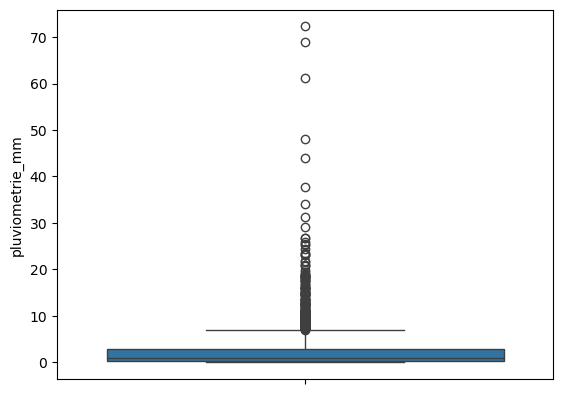

In [ ]:
sns.boxplot(df_meteo["pluviometrie_mm"])

<Axes: ylabel='demande_sang_simulee'>

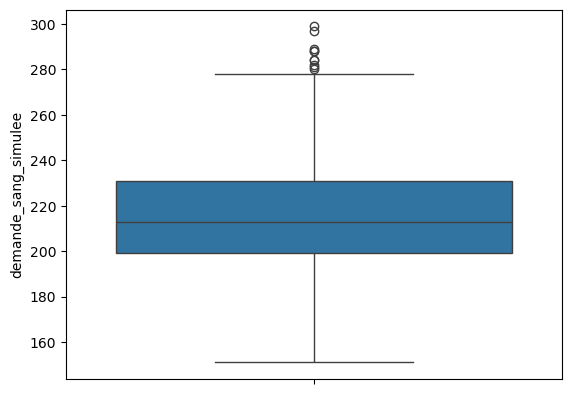

In [ ]:
sns.boxplot(df_final["demande_sang_simulee"])